# EVBattery charging snippets

This notebook lists the released vehicles from the committed snippet index, loads every snippet of one vehicle, and plots one snippet. It makes no diagnosis.

## 1. Released units

This step lists what `systems('evbattery')` reports for the release.

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import pandas as pd

ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / 'fielddata').exists())
sys.path.insert(0, str(ROOT))
from fielddata import load, systems

released = systems('evbattery')
display(released)

,unit,archive,car,label,snippets
0,battery_dataset1:0,battery_dataset1.tar.gz,0,0,2017
1,battery_dataset1:1,battery_dataset1.tar.gz,1,0,1162
2,battery_dataset1:2,battery_dataset1.tar.gz,2,0,8684
3,battery_dataset1:3,battery_dataset1.tar.gz,3,0,5423
4,battery_dataset1:4,battery_dataset1.tar.gz,4,0,8014
...,...,...,...,...,...
460,battery_dataset3:545,battery_dataset3.tar.gz,545,0,0
461,battery_dataset3:546,battery_dataset3.tar.gz,546,0,27
462,battery_dataset3:547,battery_dataset3.tar.gz,547,0,28
463,battery_dataset3:548,battery_dataset3.tar.gz,548,0,117


Each row is one labeled vehicle with its archive and snippet count. One labeled car, car 545 in battery_dataset3, has no snippets, which is why the release carries data for 464 vehicles as the paper states.

## 2. One unit as released

This step loads one unit with the default `clean=False`, so every value is as released.

In [2]:
frame = load('evbattery', unit='battery_dataset3:500')
print(frame.shape)
display(frame.head())

(2084096, 14)


,volt,current,soc,max_single_volt,min_single_volt,max_temp,min_temp,timestamp,snippet,label,charge_segment,mileage,capacity,unit
0,4.007552,-15.0,84.8,4.03175,3.99575,37.0,33.0,0.0,3794,10,182,46606.56,0,battery_dataset3:500
1,4.007292,-15.0,84.8,4.03200,3.99600,37.0,33.0,10.0,3794,10,182,46606.56,0,battery_dataset3:500
2,4.007292,-15.0,84.8,4.03300,3.99700,37.0,33.0,20.0,3794,10,182,46606.56,0,battery_dataset3:500
3,4.010417,-15.0,84.8,4.03300,3.99700,37.0,33.0,30.0,3794,10,182,46606.56,0,battery_dataset3:500
4,4.009375,-15.0,84.8,4.03300,3.99800,37.0,33.0,40.0,3794,10,182,46606.56,0,battery_dataset3:500


Each snippet is 128 rows with its own relative clock in seconds, so snippets are stacked rather than joined on time. The table also carries each snippet's charge segment, label, mileage and capacity field.

## 3. Signal ranges

This step summarises a few signals of the loaded unit.

In [3]:
display(frame[['volt', 'current', 'soc', 'max_single_volt', 'min_single_volt', 'max_temp', 'mileage']].describe().T)

,count,mean,std,min,25%,50%,75%,max
volt,2084096.0,3.983186,0.263675,3.285417,3.731250,4.086458,4.203125,4.286458
current,2084096.0,-7.348380,11.487499,-184.000000,-16.000000,0.000000,0.000000,0.000000
soc,2084096.0,77.532395,27.184719,0.400000,60.400000,90.400000,100.000000,100.000000
max_single_volt,2084096.0,4.009812,0.267710,3.421000,3.751000,4.112000,4.238000,4.300000
min_single_volt,2084096.0,3.965983,0.260900,3.176000,3.720816,4.072000,4.191000,4.284000
max_temp,2084096.0,31.700423,4.699270,16.000000,28.592177,32.501654,35.000000,45.000000
mileage,2084096.0,76935.223482,33247.236136,11890.560000,49445.088000,82637.280000,107205.120000,124780.128000


These ranges are raw values as released, before any cleaning. The schema file next to the loader lists units and any sentinel codes.

## 4. A first look

This step plots one signal to show the shape of the data.

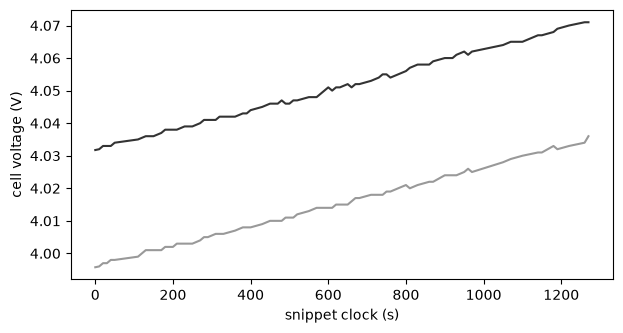

In [4]:
first = frame[frame['snippet'] == frame['snippet'].iloc[0]]
ax = first.plot(x='timestamp', y=['max_single_volt', 'min_single_volt'], figsize=(7, 3.5), color=['0.2', '0.6'], legend=False)
ax.set_xlabel('snippet clock (s)')
ax.set_ylabel('cell voltage (V)')
plt.show()

Within one snippet the two cell-voltage extremes rise together through the charge, about 35 mV apart.